In [1]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shawon10/ckplus")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ckplus' dataset.
Path to dataset files: /kaggle/input/ckplus


In [3]:
import os

# Gather unique directory paths containing images
unique_dirs = set()
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            # Get the path relative to the directory containing 'kdef-database'
            base_dir = os.path.dirname(os.path.dirname(os.path.dirname(path)))
            relative_dir = os.path.relpath(root, base_dir)
            unique_dirs.add(relative_dir)

# Print the paths (without filenames)
for d in sorted(list(unique_dirs)):
    print(f"{d}/")

kaggle/input/ckplus/CK+48/anger/
kaggle/input/ckplus/CK+48/contempt/
kaggle/input/ckplus/CK+48/disgust/
kaggle/input/ckplus/CK+48/fear/
kaggle/input/ckplus/CK+48/happy/
kaggle/input/ckplus/CK+48/sadness/
kaggle/input/ckplus/CK+48/surprise/
kaggle/input/ckplus/ck/CK+48/anger/
kaggle/input/ckplus/ck/CK+48/contempt/
kaggle/input/ckplus/ck/CK+48/disgust/
kaggle/input/ckplus/ck/CK+48/fear/
kaggle/input/ckplus/ck/CK+48/happy/
kaggle/input/ckplus/ck/CK+48/sadness/
kaggle/input/ckplus/ck/CK+48/surprise/


In [4]:
import os
import kagglehub

# Ensure path is defined
path = kagglehub.dataset_download("shawon10/ckplus")

# Define the two paths to compare
dir1 = os.path.join(path, "CK+48")
dir2 = os.path.join(path, "ck", "CK+48")

def get_relative_files(base_dir):
    rel_files = set()
    for root, _, files in os.walk(base_dir):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                rel_path = os.path.relpath(os.path.join(root, f), base_dir)
                rel_files.add(rel_path)
    return rel_files

# Get the sets of relative file paths
files1 = get_relative_files(dir1)
files2 = get_relative_files(dir2)

# Compare the sets
if files1 == files2:
    print("Both directories contain the exact same image files.")
    print(f"Total images in each directory: {len(files1)}")
else:
    print("The directories contain different files.")
    print(f"Images only in CK+48: {len(files1 - files2)}")
    print(f"Images only in ck/CK+48: {len(files2 - files1)}")

Using Colab cache for faster access to the 'ckplus' dataset.
Both directories contain the exact same image files.
Total images in each directory: 981


In [5]:
import os
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# Define the target directory to avoid duplicates
target_dir = os.path.join(path, "CK+48")

# Class mapping based on your requested names
class_mapping = {
    'anger': 'Angry',
    'disgust': 'Disgust',
    'fear': 'Fear',
    'happy': 'Happy',
    'sadness': 'Sad',
    'surprise': 'Surprise'
}

# 1. Gather image files and their new labels
image_files = []
image_labels = []

for root, dirs, files in os.walk(target_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            original_class = os.path.basename(root)
            # Only include files that are in our recognized class folders
            if original_class in class_mapping:
                image_files.append(os.path.join(root, file))
                image_labels.append(class_mapping[original_class])

print(f"Found {len(image_files)} images in {target_dir}.")
print(f"Classes mapped to: {set(image_labels)}")

Found 927 images in /kaggle/input/ckplus/CK+48.
Classes mapped to: {'Surprise', 'Fear', 'Sad', 'Disgust', 'Happy', 'Angry'}


In [6]:
# 2. Define the preprocessing pipeline
# Standard ImageNet normalization values are often used when resizing to 224x224
preprocess_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),        # Resize to 224x224
    transforms.Lambda(lambda x: x.convert("RGB")), # Convert to RGB (3 channels)
    transforms.ToTensor(),                # Convert to Tensor (0-1 range)
    transforms.Normalize(                 # Normalize
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 3. Apply to a sample image
if image_files:
    sample_image_path = image_files[0]
    original_image = Image.open(sample_image_path)

    # Apply preprocessing
    processed_tensor = preprocess_pipeline(original_image)

    print(f"Original Size: {original_image.size}")
    print(f"Processed Tensor Shape: {processed_tensor.shape}")
    print(f"Tensor Stats - Min: {processed_tensor.min():.3f}, Max: {processed_tensor.max():.3f}, Mean: {processed_tensor.mean():.3f}")
else:
    print("No images found to process.")

Original Size: (48, 48)
Processed Tensor Shape: torch.Size([3, 224, 224])
Tensor Stats - Min: -2.067, Max: 2.640, Mean: 0.441


In [7]:
import os
import torch
from tqdm import tqdm

# Define output directory in Drive
output_dir = '/content/drive/MyDrive/processed_ck_pt'

print(f"Saving processed tensors to: {output_dir}")

# We will use the 'preprocess_pipeline' defined in the previous cell
# because it already contains ToTensor() and Normalize().

# Process and save all images
successful_saves = 0

# We need the root path of the dataset to calculate relative paths
dataset_root = path

for img_path, label in tqdm(zip(image_files, image_labels), total=len(image_files), desc="Processing Images"):
    try:
        # Open image
        img = Image.open(img_path)

        # Apply full preprocessing pipeline (returns a torch.Tensor)
        processed_tensor = preprocess_pipeline(img)

        # Extract the base directory part (e.g., 'CK+48')
        base_rel_dir = os.path.relpath(os.path.dirname(os.path.dirname(img_path)), dataset_root)

        # Construct the new relative path using the mapped class label
        file_name = os.path.basename(img_path)
        rel_path_pt = os.path.join(base_rel_dir, label, os.path.splitext(file_name)[0] + '.pt')

        # Construct full save path
        save_path = os.path.join(output_dir, rel_path_pt)

        # Ensure the subdirectory exists
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

        # Save as a PyTorch tensor file
        torch.save(processed_tensor, save_path)
        successful_saves += 1
    except Exception as e:
        print(f"Error processing {img_path}: {e}")

print(f"Successfully saved {successful_saves} tensors to Google Drive, preserving directory structure with updated class names.")


Saving processed tensors to: /content/drive/MyDrive/processed_ck_ptx


Processing Images: 100%|██████████| 927/927 [00:18<00:00, 50.65it/s]

Successfully saved 927 tensors to Google Drive, preserving directory structure with updated class names.


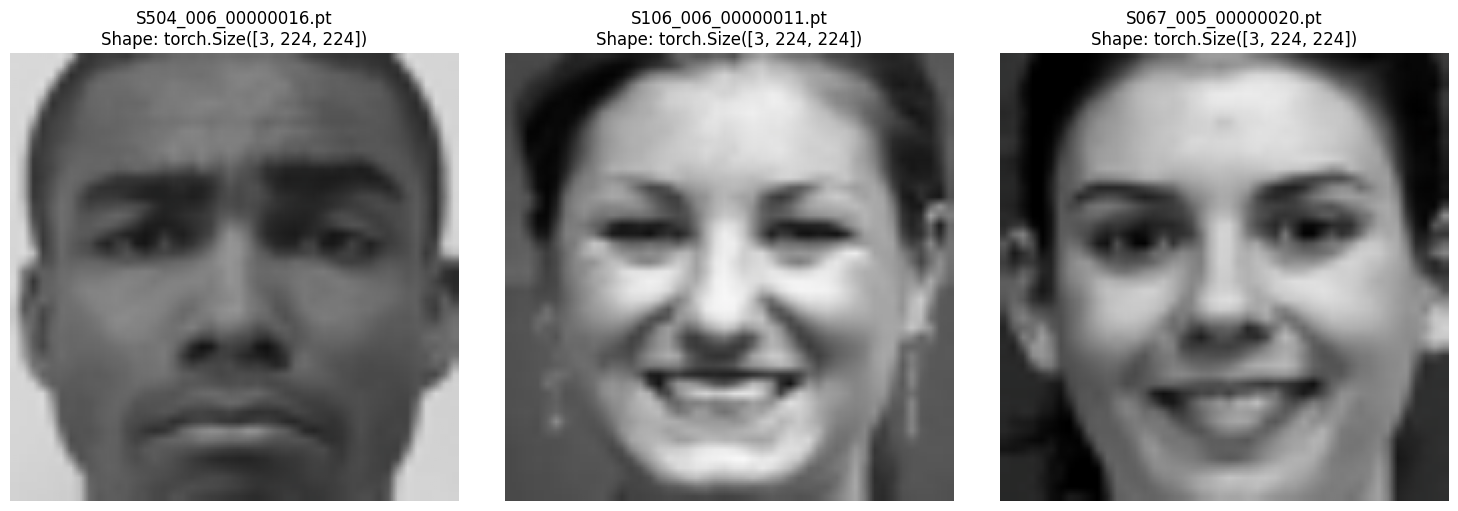

In [8]:
import os
import random
import torch
import matplotlib.pyplot as plt

saved_dir = '/content/drive/MyDrive/processed_ck_pt'

# Gather all saved .pt file paths
saved_files = []
for root, dirs, files in os.walk(saved_dir):
    for file in files:
        if file.endswith('.pt'):
            saved_files.append(os.path.join(root, file))

# Display a few samples visually
if saved_files:
    num_samples = 3
    samples = random.sample(saved_files, min(len(saved_files), num_samples))

    fig, axes = plt.subplots(1, len(samples), figsize=(15, 5))
    if len(samples) == 1:
        axes = [axes]

    # ImageNet normalization stats used during preprocessing
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for ax, pt_path in zip(axes, samples):
        # Load the tensor
        tensor = torch.load(pt_path)

        # Un-normalize the tensor back to [0, 1] range for visualization
        img_tensor = tensor * std + mean

        # Convert to numpy array and rearrange dimensions to (H, W, C) for matplotlib
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = img_np.clip(0, 1) # Ensure valid range

        ax.imshow(img_np)
        ax.set_title(f"{os.path.basename(pt_path)}\nShape: {tensor.shape}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"No .pt files found in {saved_dir}")

In [9]:
import os
import pandas as pd
from collections import Counter

# Path to the directory where we saved the processed tensors
dir_path = '/content/drive/MyDrive/processed_ck_pt'

class_counts = Counter()

# Walk through the directory and count .pt files by their parent folder (class name)
if os.path.exists(dir_path):
    for root, dirs, files in os.walk(dir_path):
        for file in files:
            if file.endswith('.pt'):
                class_name = os.path.basename(root)
                class_counts[class_name] += 1

# Create a DataFrame for visualization
df_counts = pd.DataFrame({
    'Class': list(class_counts.keys()),
    'Count': list(class_counts.values())
})

# Add a Total row at the bottom
if not df_counts.empty:
    total_row = pd.DataFrame({
        'Class': ['All Classes'],
        'Count': [df_counts['Count'].sum()]
    })
    df_counts = pd.concat([df_counts, total_row], ignore_index=True)

# Display the results
display(df_counts)

,Class,Count
0,Surprise,249
1,Fear,75
2,Sad,84
3,Disgust,177
4,Happy,207
5,Angry,135
6,All Classes,927


In [10]:
import os

dir_path = '/content/drive/MyDrive/processed_ck_pt'

if os.path.exists(dir_path):
    total_files = sum(len(files) for root, dirs, files in os.walk(dir_path))
    print(f"Total files in '{dir_path}': {total_files}")
else:
    print(f"Directory '{dir_path}' does not exist.")

Total files in '/content/drive/MyDrive/processed_ck_pt': 927


In [ ]:
from google.colab import runtime
runtime.unassign()